# Import statements

In [1]:
import xarray as xr
import pop_tools
import numpy as np
import cftime
import os
import xesmf as xe

import warnings
warnings.filterwarnings('ignore')

/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/pop_tools/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
import importlib
import analysis_functions as afuncs
import cesm2_lens_utils

importlib.reload(afuncs)
importlib.reload(cesm2_lens_utils)

<module 'cesm2_lens_utils' from '/glade/u/home/cassiacai/measures/cesm2_lens_utils.py'>

# The Blob in FOSI

In [3]:
# LENS for regridding purposes
CESMLENS_var = afuncs.LENS_for_regridding() # this is Area

In [4]:
#### CESM LENS2
var = 'SST'
comp = 'atm'
directory = f'/glade/campaign/cgd/cesm/CESM2-LE/{comp}/proc/tseries/month_1/{var}/'
ens_memb_index = 0
ds_var_hist_SST, ds_var_fut_SST = afuncs.get_ds_var(directory, 'SST','atm', ens_memb_index) 

# selecting our observational time period overlap with ERA5 (1979 to 2022)
CESMLENS_SST_hist_time_slice = ds_var_hist_SST.SST.sel(time=slice('1979-01-01', '2015-01-01'))
    
CESMLENS_SST_fut_time_slice = ds_var_fut_SST.SST.sel(time=slice('2015-02-01', '2020-12-01'))

CESMLENS_SST_ds = xr.concat([CESMLENS_SST_hist_time_slice, CESMLENS_SST_fut_time_slice], dim='time')
CESMLENS_SST = CESMLENS_SST_ds.compute()

In [5]:
#### FOSI
firstyear = 1979
lastyear = 2020
field = 'TEMP'

# Mask the Arctic, the Baltic Sea, the Red Sea, and the Black Sea
grid = pop_tools.get_grid('POP_gx1v7')
mask = xr.where((grid['REGION_MASK']>0) & (grid['REGION_MASK']<9), 1, np.nan)

fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
ds_smyle_fosi = xr.open_dataset(fpath+fname)[field].isel(z_t=0)

fosi_montime_vals = [cftime.DatetimeNoLeap(1958+year, 1+month, 15) for year in range(63) for month in range(12)]
ds_smyle_fosi['time'] = fosi_montime_vals
fosi_temp = ds_smyle_fosi[ds_smyle_fosi.time['time.year'].isin(list(range(firstyear, lastyear+1)))].where(mask==1, np.nan)

In [6]:
fosi_anom_1deg_wzeros = afuncs.regrid_SMYLE(ds_smyle_fosi)
fosi_anom_1deg = fosi_anom_1deg_wzeros.where(fosi_anom_1deg_wzeros!=0, np.nan)

regridder = xe.Regridder(fosi_anom_1deg.sel(time=slice('1979-01-01','2021-01-01')), CESMLENS_SST[:,:,:], 'nearest_s2d', periodic=True)
regridded = regridder(fosi_anom_1deg.sel(time=slice('1979-01-01','2021-01-01')))

In [7]:
mean, trend, seas, features_notrend, ssta_notrend = afuncs.calculate_anomalies_trend_features_linear(
    regridded)

In [8]:
# defining our region (North Pacific Ocean)
upper_lat = 65
lower_lat = 5
left_lon = 150
right_lon = 250

mask_1deg = ~np.isnan(regridded.isel(time=0))
regridded_features_no_trend_NEP = features_notrend.sel(lon=slice(left_lon, right_lon), lat=slice(lower_lat,upper_lat))
regridded_ssta_no_trend_NEP = ssta_notrend.sel(lon=slice(left_lon, right_lon), lat=slice(lower_lat,upper_lat))
mask_1deg_NEP = mask_1deg.sel(lon=slice(left_lon, right_lon), lat=slice(lower_lat,upper_lat))

In [9]:
# --- Save so you never have to regenerate this again ---
regridded_ssta_no_trend_NEP.to_netcdf('/glade/derecho/scratch/cassiacai/regridded_ssta_no_trend_NEP.nc')
regridded_features_no_trend_NEP.to_netcdf('/glade/derecho/scratch/cassiacai/regridded_features_no_trend_NEP.nc')
mask_1deg_NEP.to_netcdf('/glade/derecho/scratch/cassiacai/mask_1deg_NEP.nc')

print("Saved all three to Derecho scratch.")

Saved all three to Derecho scratch.


In [10]:
print(regridded_ssta_no_trend_NEP.sel(time='2015-07').max().values)  # should be close to 2.34, the confirmed FOSI Blob event max


2.3448744454154564


In [62]:
import xarray as xr
import numpy as np

fosi_blobs = xr.open_dataset('fosi_blobs_r2.nc').labels

print(fosi_blobs.dims, fosi_blobs.shape)
print(fosi_blobs.time.values[0], fosi_blobs.time.values[-1])

# --- Restrict to the known Blob period + NEP region as a first filter ---
blob_period = fosi_blobs.sel(time=slice('2013-06', '2016-06'))  # pad beyond known bounds
blob_region = blob_period.sel(lat=slice(20, 62), lon=slice(180, 250))  # adjust to your NEP domain/convention

# --- Find which label ID(s) actually appear in this space-time window ---
unique_ids = np.unique(blob_region.values)
unique_ids = unique_ids[~np.isnan(unique_ids)]
unique_ids = unique_ids[unique_ids > 0]  # drop the 0/background label
print("Label IDs present in NEP 2013-2016 window:", unique_ids)

# --- For each candidate ID, check its full lifetime (may extend outside your initial window) ---
for lid in unique_ids:
    mask = (fosi_blobs == lid)
    times_present = fosi_blobs.time.where(mask.any(dim=('lat', 'lon')), drop=True)
    n_months = len(times_present)
    print(f"Label {lid}: {n_months} months, "
          f"{str(times_present.values[0])[:7]} to {str(times_present.values[-1])[:7]}, "
          f"peak area (gridcells) = {int(mask.sum(dim=('lat','lon')).max())}")

('time', 'lat', 'lon') (504, 64, 81)
1979-01-15 00:00:00 2020-12-15 00:00:00
Label IDs present in NEP 2013-2016 window: [ 91.  92.  93.  94.  96.  99. 100.]
Label 91.0: 1 months, 2013-08 to 2013-08, peak area (gridcells) = 340
Label 92.0: 4 months, 2013-12 to 2014-03, peak area (gridcells) = 584
Label 93.0: 1 months, 2014-03 to 2014-03, peak area (gridcells) = 209
Label 94.0: 20 months, 2014-05 to 2015-12, peak area (gridcells) = 1859
Label 96.0: 1 months, 2014-06 to 2014-06, peak area (gridcells) = 109
Label 99.0: 10 months, 2016-02 to 2016-11, peak area (gridcells) = 778
Label 100.0: 7 months, 2016-03 to 2016-09, peak area (gridcells) = 664


In [80]:
BLOB_ID = 94.0
blob_mask = (fosi_blobs == BLOB_ID)

# Trim to just the months where it actually exists (drops the all-zero padding)
blob_times = fosi_blobs.time.where(blob_mask.any(dim=('lat', 'lon')), drop=True)
blob_mask = blob_mask.sel(time=blob_times)

print(f"Blob duration: {len(blob_times)} months")
print(f"Start: {str(blob_times.values[0])[:10]}, End: {str(blob_times.values[-1])[:10]}")

Blob duration: 20 months
Start: 2014-05-15, End: 2015-12-15


In [81]:
blobs_nan = fosi_blobs.sel(time=blob_times)
dates = blobs_nan.time.values

print(len(dates))
print(dates[0], dates[-1])

20
2014-05-15 00:00:00 2015-12-15 00:00:00


In [65]:
# Recompute the canonical footprint and stats using the confirmed Blob mask
canonical_footprint = blob_mask.any(dim='time').astype(int)

sst_masked = ssta_notrend.sel(time=blob_times).where(blob_mask)
areaavg_ssta_ts = sst_masked.mean(dim=('lat', 'lon'))

duration_months = len(blob_times)
event_max_ssta = float(sst_masked.max())
areaavg_max_ssta = float(areaavg_ssta_ts.max())
areaavg_max_time = areaavg_ssta_ts.idxmax(dim='time').values

print(f"Duration:               {duration_months} months")
print(f"Event maximum SSTa:     {event_max_ssta:.2f} °C")
print(f"Area-averaged max SSTa: {areaavg_max_ssta:.2f} °C  (at {str(areaavg_max_time)[:10]})")

Duration:               20 months
Event maximum SSTa:     2.34 °C
Area-averaged max SSTa: 1.11 °C  (at 2015-10-15)


In [66]:
LABEL_92 = 92.0
mask_92 = (fosi_blobs == LABEL_92)
times_92 = fosi_blobs.time.where(mask_92.any(dim=('lat', 'lon')), drop=True)
mask_92 = mask_92.sel(time=times_92)

print(f"Label 92 duration: {len(times_92)} months")
print(f"Start: {str(times_92.values[0])[:10]}, End: {str(times_92.values[-1])[:10]}")
print(f"Peak area: {int(mask_92.sum(dim=('lat','lon')).max())} gridcells")

Label 92 duration: 4 months
Start: 2013-12-15, End: 2014-03-15
Peak area: 584 gridcells


In [70]:
t_92_end = times_92.values[-1]
t_94_start = blob_times.values[0]

gap_months = (t_94_start.year - t_92_end.year) * 12 + (t_94_start.month - t_92_end.month)
print(f"Gap between Label 92 end and Label 94 start: {gap_months} month(s)")
print(f"Label 92 ends: {t_92_end}, Label 94 starts: {t_94_start}")

Gap between Label 92 end and Label 94 start: 2 month(s)
Label 92 ends: 2014-03-15 00:00:00, Label 94 starts: 2014-05-15 00:00:00


In [71]:
gap_days = (t_94_start - t_92_end).days
print(f"Gap in days: {gap_days}")

Gap in days: 61


In [68]:
# --- Spatial overlap: does 92's footprint spatially overlap where 94 later appears? ---
footprint_92 = mask_92.any(dim='time')
footprint_94 = blob_mask.any(dim='time')  # from Label 94, previous cell

overlap = footprint_92 & footprint_94
n_overlap = int(overlap.sum())
n_92_total = int(footprint_92.sum())
n_94_total = int(footprint_94.sum())

print(f"Label 92 footprint size: {n_92_total} gridcells")
print(f"Label 94 footprint size: {n_94_total} gridcells")
print(f"Overlapping gridcells:   {n_overlap}  ({100*n_overlap/n_92_total:.1f}% of Label 92's footprint)")

Label 92 footprint size: 750 gridcells
Label 94 footprint size: 3166 gridcells
Overlapping gridcells:   617  (82.3% of Label 92's footprint)


In [90]:
mask_3 = xr.open_dataset('mean_mask_3.nc').mhw_obj
mask_3 = xr.where(mask_3 > 0.1, 1, 0)
blob_mask_nan = mask_3
blob_mask = mask_3

In [88]:
i = 0  # or whatever index you're testing
print(blobs_nan[i,:,:].min().values, blobs_nan[i,:,:].max().values)

import numpy as np
print(np.isnan(blobs_nan[i,:,:].values).all())
print(np.unique(blobs_nan[i,:,:].values))

blobs_nan = blobs_nan.fillna(0)

94.0 94.0
False
[94. nan]


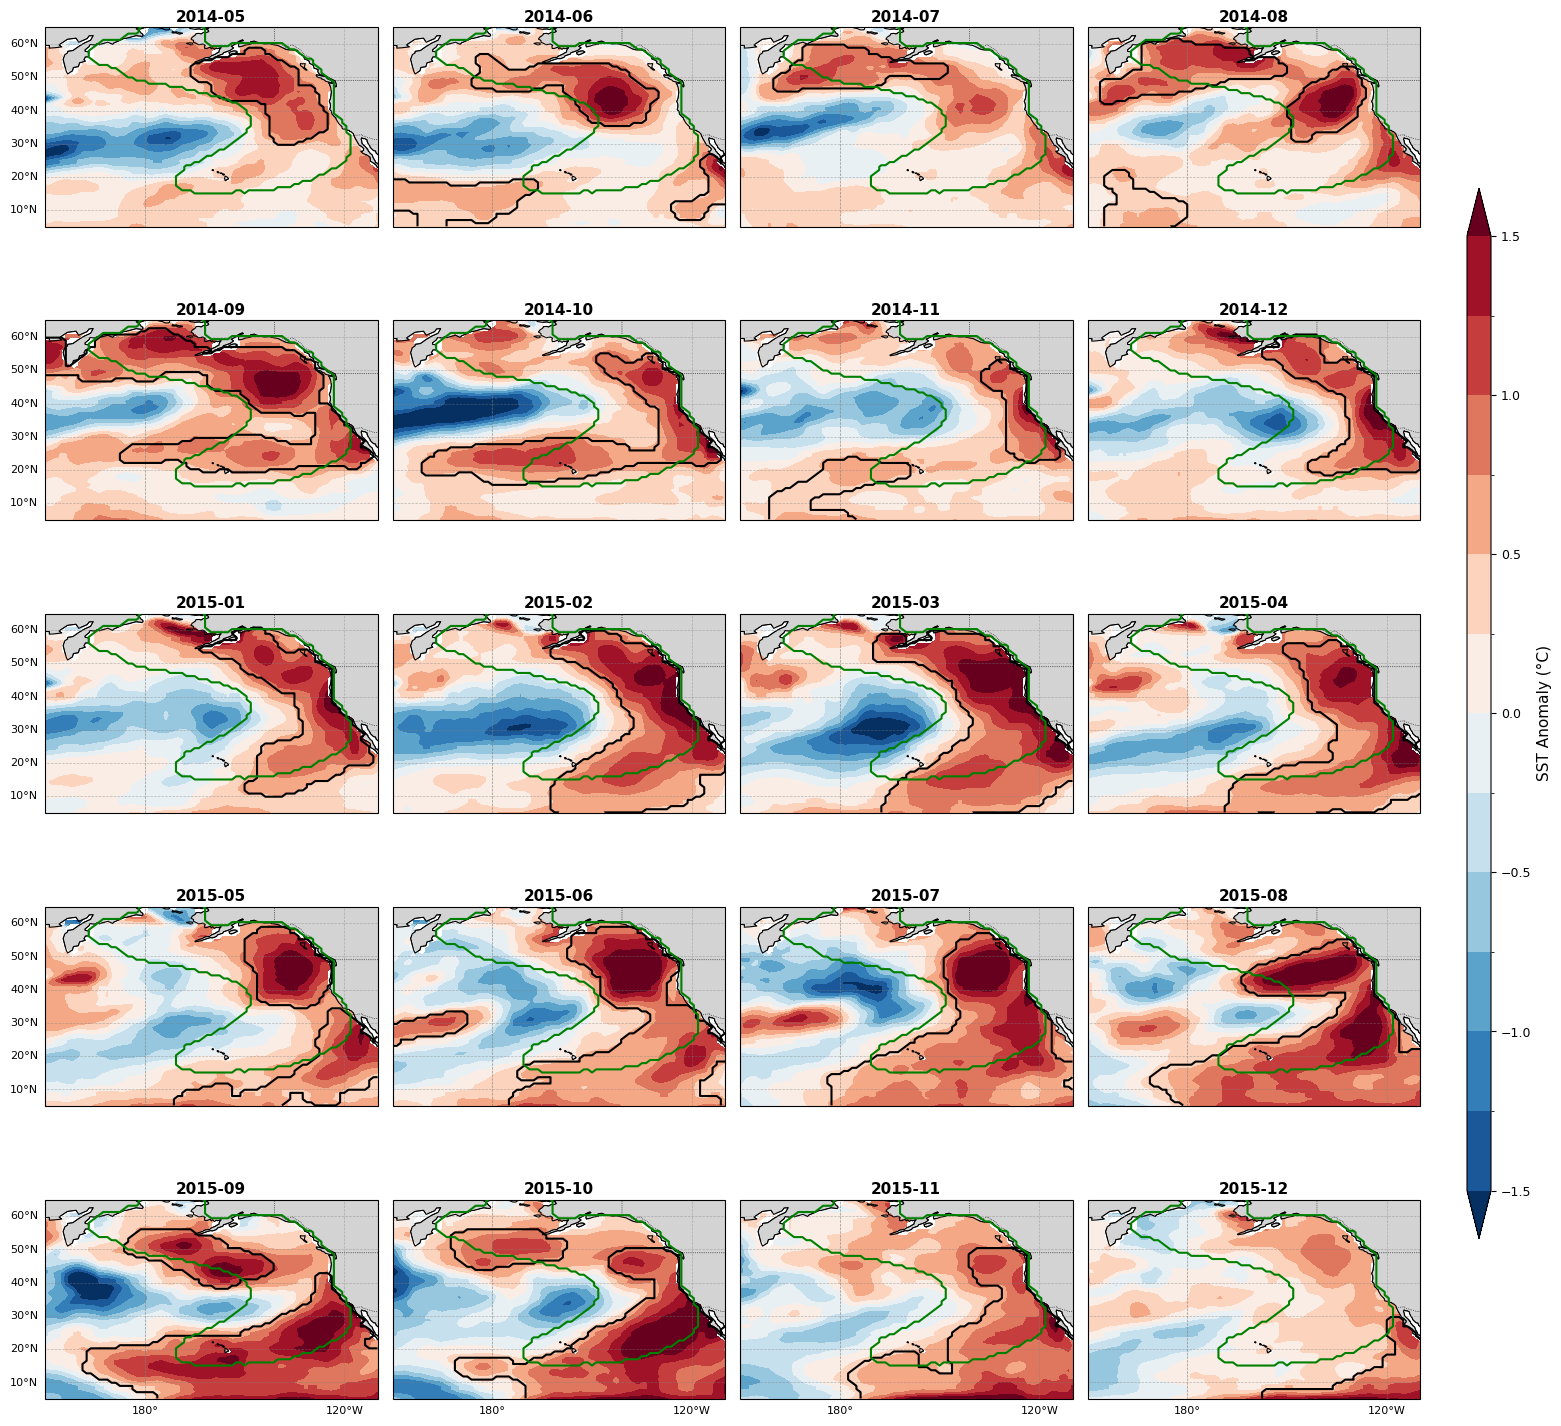

In [92]:
n_times = len(blobs_nan.time)
ncols = 4
nrows = int(np.ceil(n_times / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(4*ncols, 3*nrows),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}
)
axes = axes.flatten()

for i in range(n_times):
    ax = axes[i]
    date_str = pd.to_datetime(str(dates[i])).strftime('%Y-%m')

    ax.add_feature(cfeature.LAND, facecolor='lightgrey', edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % ncols == 0)
    gl.bottom_labels = (i >= n_times - ncols)
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

    im = regridded_ssta_no_trend_NEP.sel(time=dates[i]).plot.contourf(
        ax=ax, transform=ccrs.PlateCarree(),
        vmin=-1.5, vmax=1.5, levels=np.linspace(-1.5, 1.5, 13),
        cmap='RdBu_r', extend='both', add_colorbar=False
    )

    blobs_nan[i,:,:].plot.contour(
            ax=ax,
            transform=ccrs.PlateCarree(),
            levels=[0.5],
            colors='k',
            linewidths=1.5,
            zorder=20
        )

    blob_mask.plot.contour(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=[0.5],
        colors='green',
        linewidths=1.5,
        zorder=20
    )

    ax.set_extent([150, 250, 5, 65], crs=ccrs.PlateCarree())
    ax.set_title(date_str, fontsize=11, fontweight='bold', pad=4)

for j in range(n_times, len(axes)):
    axes[j].axis('off')

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('SST Anomaly (°C)', fontsize=11)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

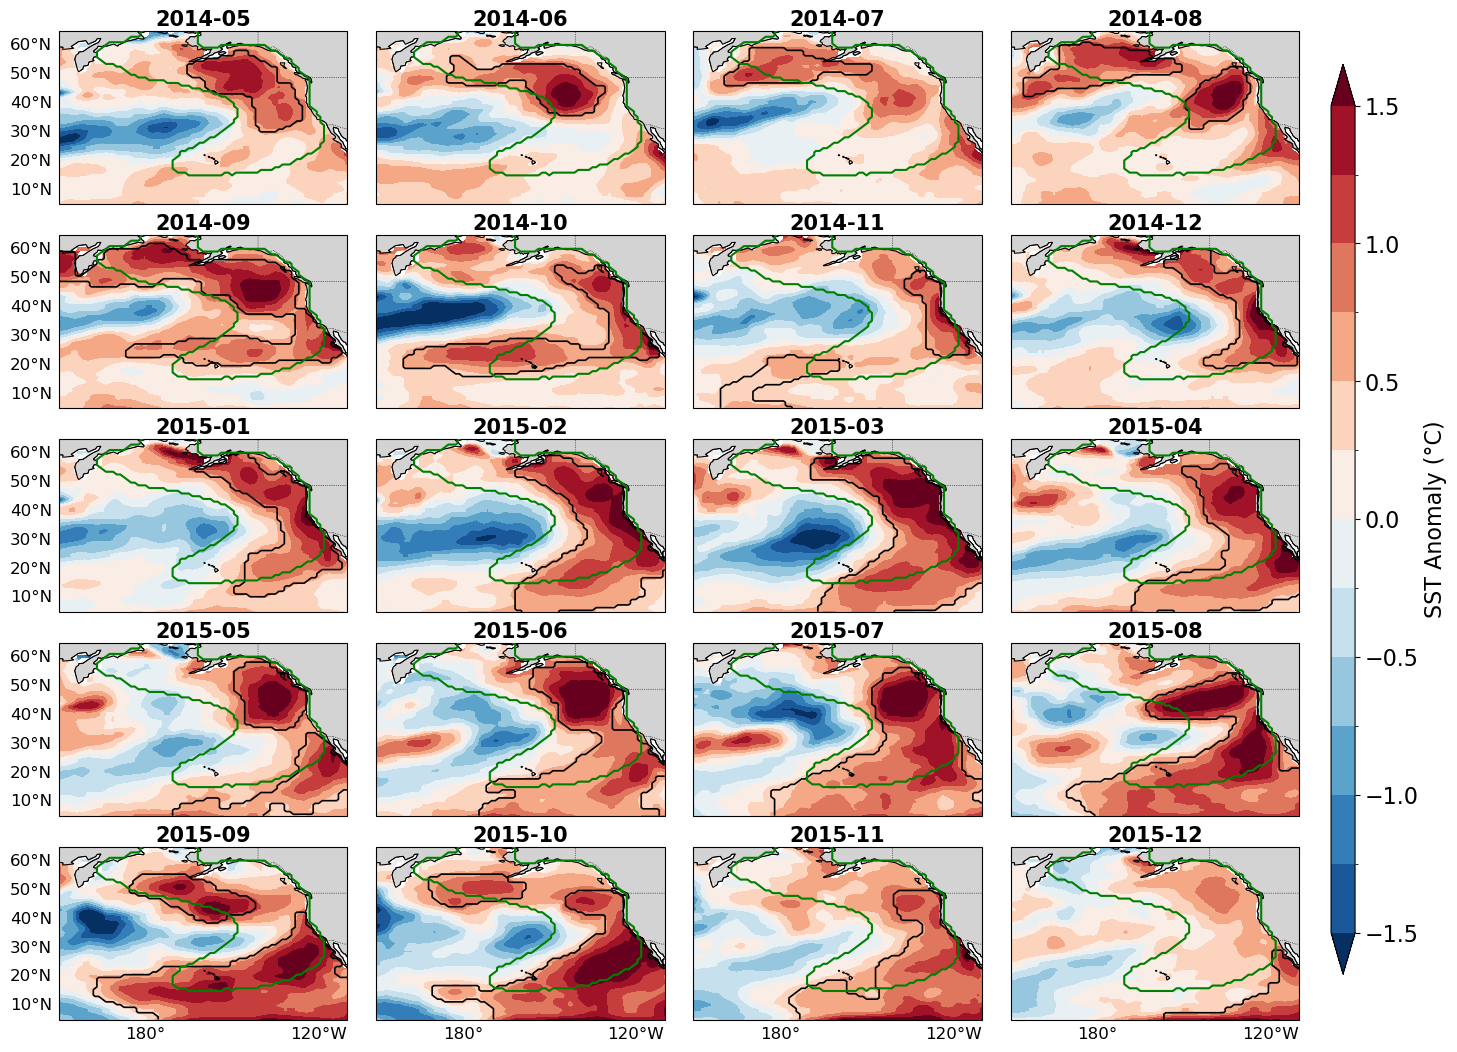

In [150]:
n_times = len(blobs_nan.time)
ncols = 4
nrows = int(np.ceil(n_times / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(4*ncols, 2.6*nrows),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}
)
axes = axes.flatten()

for i in range(n_times):
    ax = axes[i]
    date_str = pd.to_datetime(str(dates[i])).strftime('%Y-%m')

    ax.add_feature(cfeature.LAND, facecolor='lightgrey', edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

    # Labels kept, gridlines themselves invisible
    gl = ax.gridlines(draw_labels=True, linewidth=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % ncols == 0)
    gl.bottom_labels = (i >= n_times - ncols)
    gl.xlabel_style = {'size': 12}
    gl.ylabel_style = {'size': 12}

    im = regridded_ssta_no_trend_NEP.sel(time=dates[i]).plot.contourf(
        ax=ax, transform=ccrs.PlateCarree(),
        vmin=-1.5, vmax=1.5, levels=np.linspace(-1.5, 1.5, 13),
        cmap='RdBu_r', extend='both', add_colorbar=False
    )

    blobs_nan[i, :, :].plot.contour(
        ax=ax, transform=ccrs.PlateCarree(),
        levels=[0.5], colors='k', linewidths=1.2, zorder=20
    )

    blob_mask.plot.contour(
            ax=ax,
            transform=ccrs.PlateCarree(),
            levels=[0.5],
            colors='green',
            linewidths=1.5,
            zorder=20
        )

    ax.set_extent([150, 250, 5, 65], crs=ccrs.PlateCarree())
    ax.set_title(date_str, fontsize=15, fontweight='bold', pad=4)


for j in range(n_times, len(axes)):
    axes[j].axis('off')

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('SST Anomaly (°C)', fontsize=16)
cbar.ax.tick_params(labelsize=16)

plt.subplots_adjust(hspace=0.1, wspace=0.1)
plt.show()

In [128]:
blobs_nan = xr.where(fosi_blobs.sel(time=blob_times) == 94.0, 1, 0)
print(np.unique(blobs_nan.values))  # should show [0. 1.]
print((blobs_nan == 1).sum().values)  # should be > 0

[0 1]
20884


In [129]:
sst_masked = regridded_ssta_no_trend_NEP.sel(time=blob_times).where(blobs_nan == 1)
areaavg_ssta_ts = sst_masked.mean(dim=('lat', 'lon'))

event_max_ssta = float(sst_masked.max())
event_max_time = sst_masked.where(sst_masked == sst_masked.max(), drop=True).time.values
event_max_time = event_max_time[0] if len(event_max_time) else None

areaavg_max_ssta = float(areaavg_ssta_ts.max())
areaavg_max_time = blob_times[int(areaavg_ssta_ts.argmax('time').values)]

areaavg_mean_ssta = float(areaavg_ssta_ts.mean())
areaavg_std_ssta = float(areaavg_ssta_ts.std())

print(f"Event maximum SSTa (single gridpoint, whole event): {event_max_ssta:.2f} °C  (at {str(event_max_time)[:10]})")
print(f"Area-averaged max SSTa:  {areaavg_max_ssta:.2f} °C  (at {str(areaavg_max_time)[:10]})")
print(f"Area-averaged mean SSTa (over event duration): {areaavg_mean_ssta:.2f} ± {areaavg_std_ssta:.2f} °C")

Event maximum SSTa (single gridpoint, whole event): 2.34 °C  (at 2015-07-15)
Area-averaged max SSTa:  1.11 °C  (at <xarray.Da)
Area-averaged mean SSTa (over event duration): 0.99 ± 0.09 °C


In [130]:
areaavg_max_idx = int(areaavg_ssta_ts.argmax('time').values)
areaavg_max_time = areaavg_ssta_ts.time.values[areaavg_max_idx]
print(f"Area-averaged max SSTa: {areaavg_max_ssta:.2f} °C (at {str(areaavg_max_time)[:10]})")

Area-averaged max SSTa: 1.11 °C (at 2015-10-15)


In [132]:
# Compare the two masks directly
mask_3_binary = xr.where(mask_3 > 0.1, 1, 0)

# Static (time-collapsed) comparison, if mask_3 has no time dim or is already canonical/2D
if 'time' in mask_3_binary.dims:
    footprint_mask3 = mask_3_binary.any(dim='time').astype(int)
else:
    footprint_mask3 = mask_3_binary

footprint_94 = (blobs_nan == 1).any(dim='time').astype(int)

overlap = footprint_mask3 & footprint_94
print(f"mask_3 footprint size:  {int(footprint_mask3.sum())} gridcells")
print(f"Label 94 footprint size: {int(footprint_94.sum())} gridcells")
print(f"Overlap: {int(overlap.sum())} gridcells")

mask_3 footprint size:  1783 gridcells
Label 94 footprint size: 3166 gridcells
Overlap: 1527 gridcells


In [133]:
mask_3_binary = xr.where(mask_3 > 0.1, 1, 0)

# If mask_3 is static (no time dim), broadcast against the SSTa time series;
# if it has a time dim, subset to blob_times first
if 'time' in mask_3_binary.dims:
    mask_3_binary = mask_3_binary.sel(time=blob_times) if len(mask_3_binary.time) > 1 else mask_3_binary.isel(time=0)

sst_masked_canonical = regridded_ssta_no_trend_NEP.sel(time=blob_times).where(mask_3_binary == 1)
areaavg_ssta_canonical = sst_masked_canonical.mean(dim=('lat', 'lon'))

event_max_ssta_canonical = float(sst_masked_canonical.max())
event_max_time_canonical = sst_masked_canonical.where(
    sst_masked_canonical == sst_masked_canonical.max(), drop=True
).time.values
event_max_time_canonical = event_max_time_canonical[0] if len(event_max_time_canonical) else None

areaavg_max_ssta_canonical = float(areaavg_ssta_canonical.max())
areaavg_max_idx = int(areaavg_ssta_canonical.argmax('time').values)
areaavg_max_time_canonical = areaavg_ssta_canonical.time.values[areaavg_max_idx]

areaavg_mean_canonical = float(areaavg_ssta_canonical.mean())
areaavg_std_canonical = float(areaavg_ssta_canonical.std())

print(f"[Canonical mask_3] Event max SSTa: {event_max_ssta_canonical:.2f} °C (at {str(event_max_time_canonical)[:10]})")
print(f"[Canonical mask_3] Area-avg max SSTa: {areaavg_max_ssta_canonical:.2f} °C (at {str(areaavg_max_time_canonical)[:10]})")
print(f"[Canonical mask_3] Area-avg mean SSTa: {areaavg_mean_canonical:.2f} ± {areaavg_std_canonical:.2f} °C")

[Canonical mask_3] Event max SSTa: 2.34 °C (at 2015-07-15)
[Canonical mask_3] Area-avg max SSTa: 0.87 °C (at 2014-09-15)
[Canonical mask_3] Area-avg mean SSTa: 0.60 ± 0.14 °C


In [120]:
# --- Spatial extent stats ---
R = 6371.0  # km
dlat = np.deg2rad(np.mean(np.diff(blobs_nan.lat.values)))
dlon = np.deg2rad(np.mean(np.diff(blobs_nan.lon.values)))
cell_area = (R**2) * dlat * dlon * np.cos(np.deg2rad(blobs_nan.lat))
cell_area_da = xr.DataArray(cell_area.values, coords={'lat': blobs_nan.lat}, dims='lat')

extent_ts = blobs_nan * cell_area_da  # blobs_nan already 0/1
spatial_extent_km2 = extent_ts.sum(dim=('lat', 'lon'))

mean_extent = float(spatial_extent_km2.mean())
max_extent = float(spatial_extent_km2.max())
max_extent_time = blob_times[int(spatial_extent_km2.argmax('time').values)]

print(f"Mean spatial extent:    {mean_extent:,.0f} km²")
print(f"Maximum spatial extent: {max_extent:,.0f} km²  (at {str(max_extent_time)[:10]})")
print()

Mean spatial extent:    1,259,582,887 km²
Maximum spatial extent: 2,280,536,894 km²  (at <xarray.Da)



In [136]:
import numpy as np
import pandas as pd

max_extent_idx = int(spatial_extent_km2.argmax('time').values)
max_extent_km2 = float(spatial_extent_km2.max())

max_extent_time_raw = blob_times.values[max_extent_idx] if hasattr(blob_times, 'values') else blob_times[max_extent_idx]
max_extent_date = max_extent_time_raw.strftime('%B %Y')

print(f"Maximum spatial extent: {max_extent_km2:,.0f} km² in {max_extent_date}")

# --- 2. Centroid location at peak extent (and optionally at event start/end for comparison) ---
def compute_centroid(mask_2d):
    """mask_2d: boolean/0-1 DataArray with dims (lat, lon)"""
    lat2d, lon2d = xr.broadcast(mask_2d.lat, mask_2d.lon)
    weight = mask_2d.where(mask_2d > 0)
    centroid_lat = float((lat2d * weight).sum() / weight.sum())
    centroid_lon = float((lon2d * weight).sum() / weight.sum())
    return centroid_lat, centroid_lon

# Centroid at the timestep of maximum extent
mask_at_max_extent = blobs_nan.sel(time=blob_times[max_extent_idx])
centroid_lat, centroid_lon = compute_centroid(mask_at_max_extent)
print(f"Centroid at max extent ({max_extent_date}): {centroid_lat:.1f}°N, {centroid_lon:.1f}°E")

# Optional: full lat/lon bounding box at max extent, for a range description
lat_where_present = mask_at_max_extent.lat.where(mask_at_max_extent.any(dim='lon'), drop=True)
lon_where_present = mask_at_max_extent.lon.where(mask_at_max_extent.any(dim='lat'), drop=True)
print(f"Latitude range at max extent: {float(lat_where_present.min()):.0f}–{float(lat_where_present.max()):.0f}°N")
print(f"Longitude range at max extent: {float(lon_where_present.min()):.0f}–{float(lon_where_present.max()):.0f}°E")

# --- 3. Area-averaged max SSTa + date (canonical mask_3 version, already computed earlier) ---
print(f"Area-avg max SSTa: {areaavg_max_ssta_canonical:.2f} °C in "
      f"{pd.to_datetime(str(areaavg_max_time_canonical)).strftime('%B %Y')}")
print(f"Area-avg mean SSTa: {areaavg_mean_canonical:.2f} ± {areaavg_std_canonical:.2f} °C")

Maximum spatial extent: 2,280,536,894 km² in September 2015
Centroid at max extent (September 2015): 22.7°N, 210.6°E
Latitude range at max extent: 5–55°N
Longitude range at max extent: 162–250°E
Area-avg max SSTa: 0.87 °C in September 2014
Area-avg mean SSTa: 0.60 ± 0.14 °C


In [137]:
# Sanity check: what's a single gridcell's area near the equator?
print(f"dlat (rad): {dlat}, dlon (rad): {dlon}")
print(f"Single equatorial gridcell area: {(R**2) * dlat * dlon:.1f} km²")
# Should be roughly 10,000-15,000 km² for a ~1° grid, not orders of magnitude more/less

dlat (rad): 0.016448129076386354, dlon (rad): 0.02181661564992912
Single equatorial gridcell area: 14565.3 km²


In [138]:
print(int((blobs_nan.sel(time=blob_times[max_extent_idx]) == 1).sum().values))  # should be ~hundreds, not tens of thousands

1859


In [139]:
# Recompute cell area, verified
R = 6371.0  # km
dlat = np.deg2rad(np.mean(np.diff(blobs_nan.lat.values)))
dlon = np.deg2rad(np.mean(np.diff(blobs_nan.lon.values)))
cell_area = (R**2) * dlat * dlon * np.cos(np.deg2rad(blobs_nan.lat))
cell_area_da = xr.DataArray(cell_area.values, coords={'lat': blobs_nan.lat}, dims='lat')

print(f"Equatorial gridcell area check: {float(cell_area_da.sel(lat=blobs_nan.lat.values[len(blobs_nan.lat)//2])):.1f} km²")

# --- Tracked (Label 94) extent, not canonical ---
extent_ts_tracked = (blobs_nan == 1).astype(int) * cell_area_da
spatial_extent_tracked_km2 = extent_ts_tracked.sum(dim=('lat', 'lon'))

max_extent_idx = int(spatial_extent_tracked_km2.argmax('time').values)
max_extent_km2 = float(spatial_extent_tracked_km2.max())
max_extent_time_raw = blob_times.values[max_extent_idx] if hasattr(blob_times, 'values') else blob_times[max_extent_idx]
max_extent_date = max_extent_time_raw.strftime('%B %Y')

print(f"Maximum tracked spatial extent: {max_extent_km2:,.0f} km² in {max_extent_date}")

# --- Tracked-extent area-averaged SSTa (Label 94 mask, not mask_3) ---
sst_masked_tracked = regridded_ssta_no_trend_NEP.sel(time=blob_times).where(blobs_nan == 1)
areaavg_ssta_tracked = sst_masked_tracked.mean(dim=('lat', 'lon'))

areaavg_max_ssta_tracked = float(areaavg_ssta_tracked.max())
areaavg_max_idx = int(areaavg_ssta_tracked.argmax('time').values)
areaavg_max_time_tracked = areaavg_ssta_tracked.time.values[areaavg_max_idx].strftime('%B %Y')

areaavg_mean_tracked = float(areaavg_ssta_tracked.mean())
areaavg_std_tracked = float(areaavg_ssta_tracked.std())

print(f"Area-avg max SSTa (tracked extent): {areaavg_max_ssta_tracked:.2f} °C in {areaavg_max_time_tracked}")
print(f"Area-avg mean SSTa (tracked extent): {areaavg_mean_tracked:.2f} ± {areaavg_std_tracked:.2f} °C")

# --- Centroid at max tracked extent ---
mask_at_max_extent = (blobs_nan.sel(time=blob_times[max_extent_idx]) == 1)
lat2d, lon2d = xr.broadcast(mask_at_max_extent.lat, mask_at_max_extent.lon)
weight = mask_at_max_extent.where(mask_at_max_extent)
centroid_lat = float((lat2d * weight).sum() / weight.sum())
centroid_lon = float((lon2d * weight).sum() / weight.sum())
print(f"Centroid at max tracked extent ({max_extent_date}): {centroid_lat:.1f}°N, {centroid_lon:.1f}°E")

Equatorial gridcell area check: 11881.4 km²
Maximum tracked spatial extent: 24,261,031 km² in September 2015
Area-avg max SSTa (tracked extent): 1.11 °C in October 2015
Area-avg mean SSTa (tracked extent): 0.99 ± 0.09 °C
Centroid at max tracked extent (September 2015): 22.7°N, 210.6°E


In [141]:
sst_masked_tracked = regridded_ssta_no_trend_NEP.sel(time=blob_times).where(blobs_nan == 1)

event_max_ssta_tracked = float(sst_masked_tracked.max())
event_max_time_tracked = sst_masked_tracked.where(
    sst_masked_tracked == sst_masked_tracked.max(), drop=True
).time.values
event_max_time_tracked = event_max_time_tracked[0].strftime('%B %Y') if len(event_max_time_tracked) else None

print(f"Event maximum SSTa (tracked extent): {event_max_ssta_tracked:.2f} °C in {event_max_time_tracked}")

Event maximum SSTa (tracked extent): 2.34 °C in July 2015


In [142]:
import pandas as pd

def strftime_safe(t):
    return t.strftime('%B %Y') if hasattr(t, 'strftime') else pd.to_datetime(str(t)).strftime('%B %Y')

def lon_to_west(lon_e):
    return f"{360-lon_e:.1f}°W" if lon_e > 180 else f"{lon_e:.1f}°E"

# ============ TRACKED (Label 94, per-timestep Ocetrac extent) ============
sst_masked_tracked = regridded_ssta_no_trend_NEP.sel(time=blob_times).where(blobs_nan == 1)
areaavg_ssta_tracked = sst_masked_tracked.mean(dim=('lat', 'lon'))

event_max_tracked = float(sst_masked_tracked.max())
event_max_t_tracked = sst_masked_tracked.where(sst_masked_tracked == sst_masked_tracked.max(), drop=True).time.values[0]

areaavg_max_tracked = float(areaavg_ssta_tracked.max())
areaavg_max_idx_tracked = int(areaavg_ssta_tracked.argmax('time').values)
areaavg_max_t_tracked = areaavg_ssta_tracked.time.values[areaavg_max_idx_tracked]

areaavg_mean_tracked = float(areaavg_ssta_tracked.mean())
areaavg_std_tracked = float(areaavg_ssta_tracked.std())

extent_ts_tracked = (blobs_nan == 1).astype(int) * cell_area_da
spatial_extent_tracked = extent_ts_tracked.sum(dim=('lat', 'lon'))
max_extent_idx_tracked = int(spatial_extent_tracked.argmax('time').values)
max_extent_tracked = float(spatial_extent_tracked.max())
max_extent_t_tracked = blob_times.values[max_extent_idx_tracked]

mask_peak_tracked = (blobs_nan.sel(time=blob_times[max_extent_idx_tracked]) == 1)
lat2d, lon2d = xr.broadcast(mask_peak_tracked.lat, mask_peak_tracked.lon)
w = mask_peak_tracked.where(mask_peak_tracked)
centroid_lat_tracked = float((lat2d*w).sum()/w.sum())
centroid_lon_tracked = float((lon2d*w).sum()/w.sum())

# ============ CANONICAL (mask_3, fixed NEP reference footprint) ============
mask_3_binary = xr.where(mask_3 > 0.1, 1, 0)
if 'time' in mask_3_binary.dims:
    mask_3_binary = mask_3_binary.isel(time=0) if len(mask_3_binary.time) == 1 else mask_3_binary.sel(time=blob_times)

sst_masked_canon = regridded_ssta_no_trend_NEP.sel(time=blob_times).where(mask_3_binary == 1)
areaavg_ssta_canon = sst_masked_canon.mean(dim=('lat', 'lon'))

event_max_canon = float(sst_masked_canon.max())
event_max_t_canon = sst_masked_canon.where(sst_masked_canon == sst_masked_canon.max(), drop=True).time.values[0]

areaavg_max_canon = float(areaavg_ssta_canon.max())
areaavg_max_idx_canon = int(areaavg_ssta_canon.argmax('time').values)
areaavg_max_t_canon = areaavg_ssta_canon.time.values[areaavg_max_idx_canon]

areaavg_mean_canon = float(areaavg_ssta_canon.mean())
areaavg_std_canon = float(areaavg_ssta_canon.std())

extent_canon_km2 = float((mask_3_binary * cell_area_da).sum())  # static footprint, single number

lat2d_c, lon2d_c = xr.broadcast(mask_3_binary.lat, mask_3_binary.lon)
w_c = mask_3_binary.where(mask_3_binary)
centroid_lat_canon = float((lat2d_c*w_c).sum()/w_c.sum())
centroid_lon_canon = float((lon2d_c*w_c).sum()/w_c.sum())

# ============ PRINT COMPARISON TABLE ============
print(f"{'Metric':<35}{'Tracked (Label 94)':<25}{'Canonical (mask_3)':<25}")
print("-"*85)
print(f"{'Event max SSTa (°C)':<35}{event_max_tracked:<25.2f}{event_max_canon:<25.2f}")
print(f"{'  — month':<35}{strftime_safe(event_max_t_tracked):<25}{strftime_safe(event_max_t_canon):<25}")
print(f"{'Area-avg max SSTa (°C)':<35}{areaavg_max_tracked:<25.2f}{areaavg_max_canon:<25.2f}")
print(f"{'  — month':<35}{strftime_safe(areaavg_max_t_tracked):<25}{strftime_safe(areaavg_max_t_canon):<25}")
print(f"{'Area-avg mean ± std (°C)':<35}{f'{areaavg_mean_tracked:.2f} ± {areaavg_std_tracked:.2f}':<25}{f'{areaavg_mean_canon:.2f} ± {areaavg_std_canon:.2f}':<25}")
print(f"{'Spatial extent (km²)':<35}{f'{max_extent_tracked:,.0f} (max)':<25}{f'{extent_canon_km2:,.0f} (fixed)':<25}")
print(f"{'  — month (tracked only)':<35}{strftime_safe(max_extent_t_tracked):<25}{'N/A (static)':<25}")
print(f"{'Centroid':<35}{f'{centroid_lat_tracked:.1f}°N, {lon_to_west(centroid_lon_tracked)}':<25}{f'{centroid_lat_canon:.1f}°N, {lon_to_west(centroid_lon_canon)}':<25}")

Metric                             Tracked (Label 94)       Canonical (mask_3)       
-------------------------------------------------------------------------------------
Event max SSTa (°C)                2.34                     2.34                     
  — month                          July 2015                July 2015                
Area-avg max SSTa (°C)             1.11                     0.87                     
  — month                          October 2015             September 2014           
Area-avg mean ± std (°C)           0.99 ± 0.09              0.60 ± 0.14              
Spatial extent (km²)               24,261,031 (max)         18,166,561 (fixed)       
  — month (tracked only)           September 2015           N/A (static)             
Centroid                           22.7°N, 149.4°W          42.4°N, 151.2°W          


In [143]:
mean_extent_tracked = float(spatial_extent_tracked.mean())
print(f"Mean tracked spatial extent: {mean_extent_tracked:,.0f} km²")

Mean tracked spatial extent: 12,854,675 km²


In [121]:
# --- Monthly breakdown table (useful for a supplementary table) ---
import pandas as pd

monthly_stats = pd.DataFrame({
    'date': [str(t)[:7] for t in blob_times],
    'area_avg_ssta_degC': areaavg_ssta_ts.values,
    'spatial_extent_km2': spatial_extent_km2.values,
})
print(monthly_stats.to_string(index=False))

   date  area_avg_ssta_degC  spatial_extent_km2
<xarray                 NaN        4.517541e+08
<xarray                 NaN        1.027952e+09
<xarray                 NaN        2.788368e+08
<xarray                 NaN        9.356037e+08
<xarray                 NaN        1.375997e+09
<xarray                 NaN        1.010440e+09
<xarray                 NaN        6.456288e+08
<xarray                 NaN        5.731487e+08
<xarray                 NaN        8.871099e+08
<xarray                 NaN        1.508652e+09
<xarray                 NaN        1.708370e+09
<xarray                 NaN        1.469397e+09
<xarray                 NaN        1.034491e+09
<xarray                 NaN        1.799745e+09
<xarray                 NaN        2.044881e+09
<xarray                 NaN        2.160386e+09
<xarray                 NaN        2.280537e+09
<xarray                 NaN        1.986145e+09
<xarray                 NaN        1.571834e+09
<xarray                 NaN        4.407

In [98]:
# --- Build the full continuous time window: Label 92 start through Label 94 end ---
LABEL_92 = 92.0
LABEL_94 = 94.0

mask_92 = (fosi_blobs == LABEL_92)
times_92 = fosi_blobs.time.where(mask_92.any(dim=('lat', 'lon')), drop=True)

mask_94 = (fosi_blobs == LABEL_94)
times_94 = fosi_blobs.time.where(mask_94.any(dim=('lat', 'lon')), drop=True)

# Full continuous window, including the gap
full_window_start = times_92.values[0]
full_window_end = times_94.values[-1]

combined_times = fosi_blobs.time.sel(time=slice(full_window_start, full_window_end)).values
print(f"Combined window: {str(combined_times[0])[:7]} to {str(combined_times[-1])[:7]}, {len(combined_times)} months")

# Identify which months are "gap" months (no label 92 or 94 present)
gap_times = [t for t in combined_times if t not in times_92.values and t not in times_94.values]
print(f"Gap months: {[str(t)[:7] for t in gap_times]}")

Combined window: 2013-12 to 2015-12, 25 months
Gap months: ['2014-04']


In [99]:
# --- Build a combined binary mask: 1 wherever EITHER label 92 or 94 is present, 0/NaN elsewhere ---
combined_labels = xr.where(
    (fosi_blobs.sel(time=combined_times) == LABEL_92) | (fosi_blobs.sel(time=combined_times) == LABEL_94),
    1, 0
)

regridded_full = regridded_ssta_no_trend_NEP  # or re-select if this was subsetted earlier
regridded_full = regridded_full.sel(time=combined_times) if len(regridded_full.time) != len(combined_times) else regridded_full

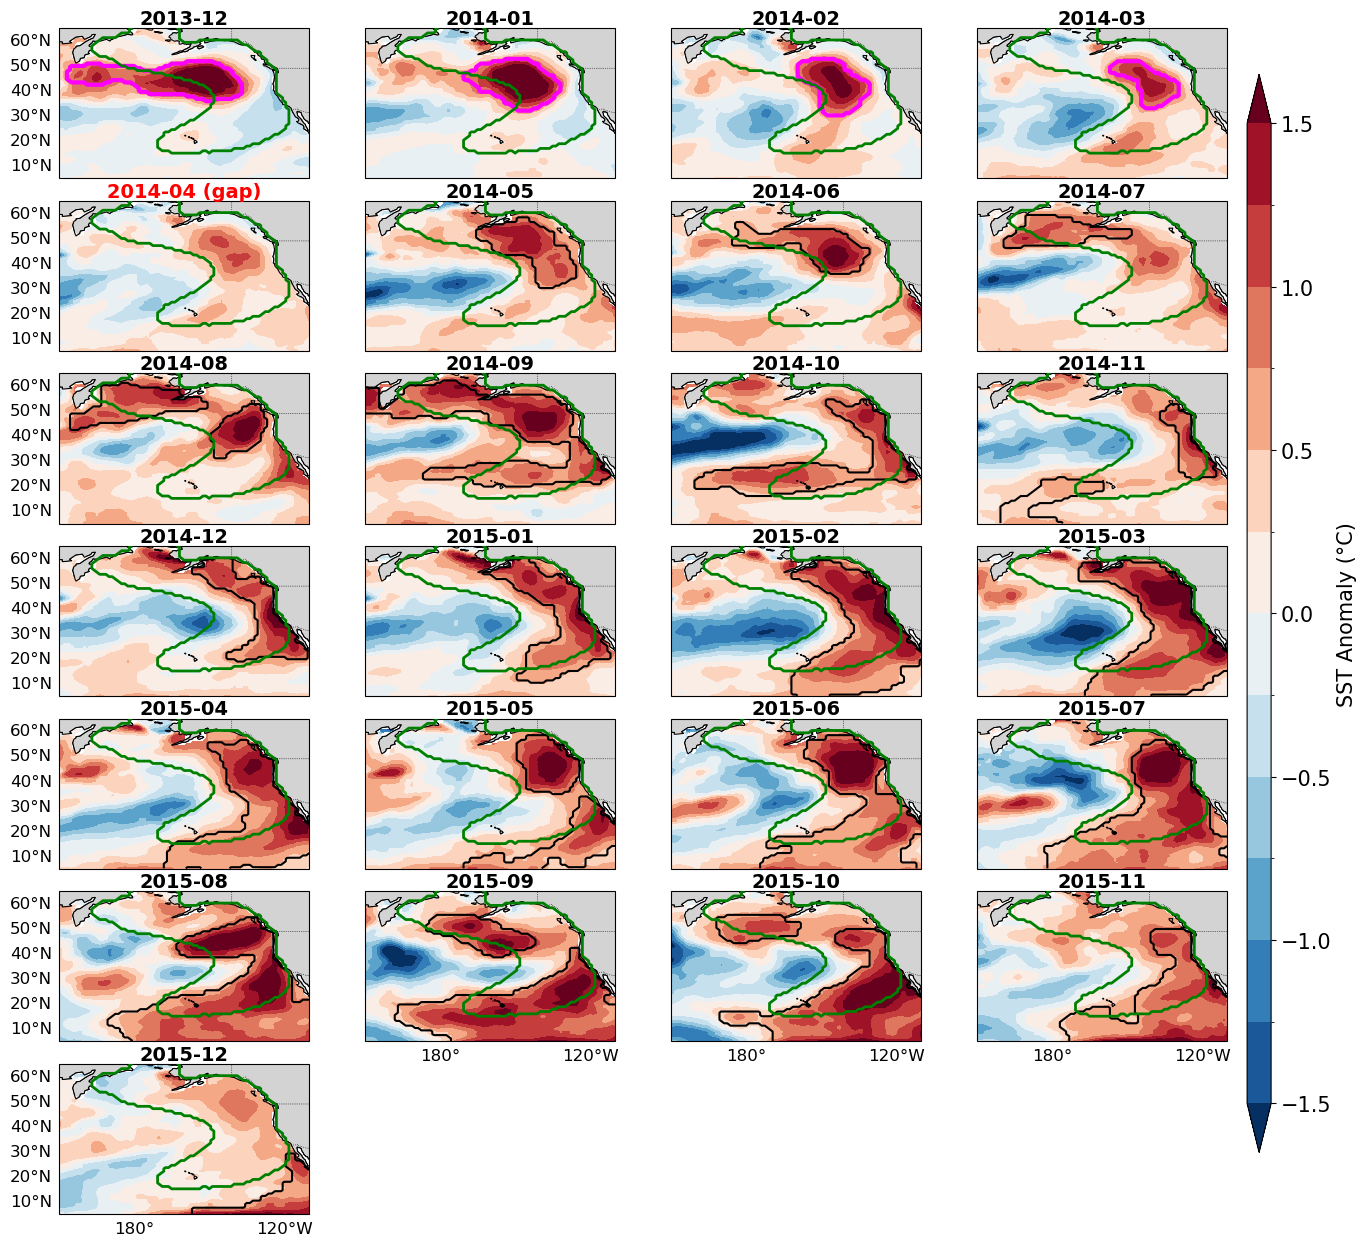

In [149]:
n_times = len(combined_times)
ncols = 4
nrows = int(np.ceil(n_times / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(4*ncols, 2.2*nrows),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}
)
axes = axes.flatten()

for i, t in enumerate(combined_times):
    ax = axes[i]
    date_str = pd.to_datetime(str(t)).strftime('%Y-%m')

    ax.add_feature(cfeature.LAND, facecolor='lightgrey', edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

    gl = ax.gridlines(draw_labels=True, linewidth=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % ncols == 0)
    gl.bottom_labels = (i >= n_times - ncols)
    gl.xlabel_style = {'size': 12}
    gl.ylabel_style = {'size': 12}

    im = regridded_full.sel(time=t).plot.contourf(
        ax=ax, transform=ccrs.PlateCarree(),
        vmin=-1.5, vmax=1.5, levels=np.linspace(-1.5, 1.5, 13),
        cmap='RdBu_r', extend='both', add_colorbar=False
    )

    # Separate contours per label so each gets its own color
    mask_92_t = xr.where(fosi_blobs.sel(time=t) == LABEL_92, 1, 0)
    mask_94_t = xr.where(fosi_blobs.sel(time=t) == LABEL_94, 1, 0)

    if mask_92_t.max() > 0:
        mask_92_t.plot.contour(
            ax=ax, transform=ccrs.PlateCarree(),
            levels=[0.5], colors='fuchsia', linewidths=3, zorder=20
        )
    if mask_94_t.max() > 0:
        mask_94_t.plot.contour(
            ax=ax, transform=ccrs.PlateCarree(),
            levels=[0.5], colors='k', linewidths=1.5, zorder=20
        )

    blob_mask.plot.contour(
            ax=ax,
            transform=ccrs.PlateCarree(),
            levels=[0.5],
            colors='green',
            linewidths=2,
            zorder=20
        )
    
    ax.set_extent([150, 250, 5, 65], crs=ccrs.PlateCarree())

    is_gap = t in gap_times
    title_suffix = ' (gap)' if is_gap else ''
    ax.set_title(date_str + title_suffix, fontsize=14, fontweight='bold', pad=2,
                 color='red' if is_gap else 'black')

for j in range(n_times, len(axes)):
    axes[j].axis('off')

cbar_ax = fig.add_axes([0.89, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('SST Anomaly (°C)', fontsize=15)
cbar.ax.tick_params(labelsize=15)

plt.subplots_adjust(hspace=0.15, wspace=-0.05)
plt.show()

In [174]:
fosi_heat_budget = xr.open_dataset('/glade/derecho/scratch/cassiacai/fosi_heat_budget_155m.nc')

In [175]:
NO_SEC_IN_1_MON = 2629740

lat_slice=slice(204, 367)
lon_slice=slice(190, 280)

mean_image_pop_files = [f'/glade/derecho/scratch/cassiacai/mean_image_{i}_POP.nc' for i in range(1, 8)]
mean_images_pop = [xr.open_dataset(file) for file in mean_image_pop_files]
masks_pop = [xr.where(image.__xarray_dataarray_variable__ > 0.1, 1, 0) for image in mean_images_pop]
NEPac_MHW_renamed_latlon = NEPac_MHW = masks_pop[2][lat_slice, lon_slice].rename({'nlat': 'nlat_t', 'nlon': 'nlon_t'})

In [176]:
print(204+163, 367)  # should match if lat_slice upper bound is right... let's just verify directly
check_shape = fosi_heat_budget['TEND_TEMP'].isel(nlat_t=lat_slice, nlon_t=lon_slice).isel(time=0).shape
print(check_shape)  # should print (163, 90) to confirm these are the right slices

367 367
(163, 90)


In [177]:
TEND_TEMP_notrend_cropped = TEND_TEMP_notrend.isel(nlat_t=lat_slice, nlon_t=lon_slice)
TOT_ADV_notrend_cropped = TOT_ADV_notrend.isel(nlat_t=lat_slice, nlon_t=lon_slice)
SHF_depth_notrend_cropped = SHF_depth_notrend.isel(nlat_t=lat_slice, nlon_t=lon_slice)
QSW_3D_notrend_cropped = QSW_3D_notrend.isel(nlat_t=lat_slice, nlon_t=lon_slice)
SUBGRID_notrend_cropped = SUBGRID_notrend.isel(nlat_t=lat_slice, nlon_t=lon_slice)

# Since neither side has real nlat_t/nlon_t coordinate labels, assign the mask's coords
# onto the cropped data so the multiply aligns cleanly (rather than raising the same error again)
TEND_TEMP_notrend_cropped = TEND_TEMP_notrend_cropped.assign_coords(
    nlat_t=NEPac_MHW_renamed_latlon.nlat_t, nlon_t=NEPac_MHW_renamed_latlon.nlon_t
)
TOT_ADV_notrend_cropped = TOT_ADV_notrend_cropped.assign_coords(
    nlat_t=NEPac_MHW_renamed_latlon.nlat_t, nlon_t=NEPac_MHW_renamed_latlon.nlon_t
)
SHF_depth_notrend_cropped = SHF_depth_notrend_cropped.assign_coords(
    nlat_t=NEPac_MHW_renamed_latlon.nlat_t, nlon_t=NEPac_MHW_renamed_latlon.nlon_t
)
QSW_3D_notrend_cropped = QSW_3D_notrend_cropped.assign_coords(
    nlat_t=NEPac_MHW_renamed_latlon.nlat_t, nlon_t=NEPac_MHW_renamed_latlon.nlon_t
)
SUBGRID_notrend_cropped = SUBGRID_notrend_cropped.assign_coords(
    nlat_t=NEPac_MHW_renamed_latlon.nlat_t, nlon_t=NEPac_MHW_renamed_latlon.nlon_t
)

# Now multiply — shapes and coords match
TEND_TEMP_notrend_smaller_reg = TEND_TEMP_notrend_cropped * NEPac_MHW_renamed_latlon
TOT_ADV_notrend_smaller_reg = TOT_ADV_notrend_cropped * NEPac_MHW_renamed_latlon
SHF_depth_notrend_smaller_reg = SHF_depth_notrend_cropped * NEPac_MHW_renamed_latlon
QSW_3D_notrend_smaller_reg = QSW_3D_notrend_cropped * NEPac_MHW_renamed_latlon
SUBGRID_notrend_smaller_reg = SUBGRID_notrend_cropped * NEPac_MHW_renamed_latlon

In [178]:
for name, da in [('TEND_TEMP', TEND_TEMP_notrend_smaller_reg),
                  ('TOT_ADV', TOT_ADV_notrend_smaller_reg),
                  ('SHF_depth', SHF_depth_notrend_smaller_reg),
                  ('QSW_3D', QSW_3D_notrend_smaller_reg),
                  ('SUBGRID', SUBGRID_notrend_smaller_reg)]:
    vals = da.values if hasattr(da, 'values') else da
    print(f"{name}: shape={vals.shape}, min={np.nanmin(vals):.4f}, max={np.nanmax(vals):.4f}, "
          f"all-NaN={np.isnan(vals).all()}, all-zero={np.all(vals==0)}")

TEND_TEMP: shape=(504, 163, 90), min=-39.6169, max=35.2489, all-NaN=False, all-zero=False
TOT_ADV: shape=(504, 163, 90), min=-370.3953, max=436.1600, all-NaN=False, all-zero=False
SHF_depth: shape=(504, 163, 90), min=-66.3056, max=40.1269, all-NaN=False, all-zero=False
QSW_3D: shape=(504, 163, 90), min=-13.9546, max=14.8432, all-NaN=False, all-zero=False
SUBGRID: shape=(504, 163, 90), min=-457.2505, max=368.4184, all-NaN=False, all-zero=False


In [184]:
# Area-average each term over the Blob's time window (May 2014 - Dec 2015)
TEND_TEMP_areaavg = TEND_TEMP_notrend_smaller_reg_nan.sel(time=slice('2014-05','2015-12')).mean(dim=('nlat_t','nlon_t'))
TOT_ADV_areaavg = TOT_ADV_notrend_smaller_reg_nan.sel(time=slice('2014-05','2015-12')).mean(dim=('nlat_t','nlon_t'))
SHF_depth_areaavg = SHF_depth_notrend_smaller_reg_nan.sel(time=slice('2014-05','2015-12')).mean(dim=('nlat_t','nlon_t'))
QSW_3D_areaavg = QSW_3D_notrend_smaller_reg_nan.sel(time=slice('2014-05','2015-12')).mean(dim=('nlat_t','nlon_t'))
SUBGRID_areaavg = SUBGRID_notrend_smaller_reg_nan.sel(time=slice('2014-05','2015-12')).mean(dim=('nlat_t','nlon_t'))

for name, da in [('TEND_TEMP', TEND_TEMP_areaavg), ('TOT_ADV', TOT_ADV_areaavg),
                  ('SHF_depth', SHF_depth_areaavg), ('QSW_3D', QSW_3D_areaavg),
                  ('SUBGRID', SUBGRID_areaavg)]:
    print(f"{name}: mean={float(da.mean()):.3f}, max={float(da.max()):.3f}, min={float(da.min()):.3f}")

TEND_TEMP: mean=0.116, max=2.487, min=-2.135
TOT_ADV: mean=0.226, max=2.337, min=-1.919
SHF_depth: mean=0.047, max=4.664, min=-4.991
QSW_3D: mean=0.001, max=0.764, min=-0.772
SUBGRID: mean=-0.161, max=4.332, min=-2.665


In [185]:
residual_areaavg = TEND_TEMP_areaavg - (TOT_ADV_areaavg + SHF_depth_areaavg + QSW_3D_areaavg + SUBGRID_areaavg)
print(f"Area-averaged residual: max abs = {float(np.abs(residual_areaavg).max()):.6f}")

Area-averaged residual: max abs = 0.047504


In [186]:
import pandas as pd

months = TEND_TEMP_areaavg.time.values

print(f"{'Month':<10}{'TEND_TEMP':<12}{'TOT_ADV':<12}{'SHF_depth':<12}{'QSW_3D':<12}{'SUBGRID':<12}")
for i, t in enumerate(months):
    print(f"{t.strftime('%Y-%m'):<10}"
          f"{float(TEND_TEMP_areaavg.isel(time=i)):<12.3f}"
          f"{float(TOT_ADV_areaavg.isel(time=i)):<12.3f}"
          f"{float(SHF_depth_areaavg.isel(time=i)):<12.3f}"
          f"{float(QSW_3D_areaavg.isel(time=i)):<12.3f}"
          f"{float(SUBGRID_areaavg.isel(time=i)):<12.3f}")

Month     TEND_TEMP   TOT_ADV     SHF_depth   QSW_3D      SUBGRID     
2014-05   1.207       -1.068      2.143       0.697       -0.568      
2014-06   -0.587      0.935       -1.058      -0.293      -0.186      
2014-07   0.251       -0.991      0.025       -0.135      1.342       
2014-08   0.219       0.307       0.740       -0.128      -0.694      
2014-09   0.931       -0.659      1.760       0.764       -0.921      
2014-10   -1.006      0.439       -1.497      0.019       0.033       
2014-11   0.622       0.645       1.094       -0.258      -0.865      
2014-12   0.148       1.532       0.438       0.104       -1.923      
2015-01   2.487       0.111       4.664       0.390       -2.665      
2015-02   1.670       -0.124      3.219       -0.108      -1.313      
2015-03   -0.363      0.927       -1.102      -0.690      0.490       
2015-04   -1.458      0.054       -3.090      0.041       1.539       
2015-05   0.559       1.000       0.465       0.132       -1.018      
2015-0

In [187]:
TEND_TEMP_areaavg_ext = TEND_TEMP_notrend_smaller_reg_nan.sel(time=slice('2013-01','2016-06')).mean(dim=('nlat_t','nlon_t'))
TOT_ADV_areaavg_ext = TOT_ADV_notrend_smaller_reg_nan.sel(time=slice('2013-01','2016-06')).mean(dim=('nlat_t','nlon_t'))
SHF_depth_areaavg_ext = SHF_depth_notrend_smaller_reg_nan.sel(time=slice('2013-01','2016-06')).mean(dim=('nlat_t','nlon_t'))
QSW_3D_areaavg_ext = QSW_3D_notrend_smaller_reg_nan.sel(time=slice('2013-01','2016-06')).mean(dim=('nlat_t','nlon_t'))
SUBGRID_areaavg_ext = SUBGRID_notrend_smaller_reg_nan.sel(time=slice('2013-01','2016-06')).mean(dim=('nlat_t','nlon_t'))

months_ext = TEND_TEMP_areaavg_ext.time.values

print(f"{'Month':<10}{'TEND_TEMP':<12}{'TOT_ADV':<12}{'SHF_depth':<12}{'QSW_3D':<12}{'SUBGRID':<12}")
for i, t in enumerate(months_ext):
    print(f"{t.strftime('%Y-%m'):<10}"
          f"{float(TEND_TEMP_areaavg_ext.isel(time=i)):<12.3f}"
          f"{float(TOT_ADV_areaavg_ext.isel(time=i)):<12.3f}"
          f"{float(SHF_depth_areaavg_ext.isel(time=i)):<12.3f}"
          f"{float(QSW_3D_areaavg_ext.isel(time=i)):<12.3f}"
          f"{float(SUBGRID_areaavg_ext.isel(time=i)):<12.3f}")

Month     TEND_TEMP   TOT_ADV     SHF_depth   QSW_3D      SUBGRID     
2013-01   1.083       0.363       1.855       0.236       -1.359      
2013-02   -0.766      0.679       -0.943      0.018       -0.517      
2013-03   0.845       0.662       1.794       -0.282      -1.340      
2013-04   1.794       -2.344      2.984       -0.023      1.176       
2013-05   0.919       -0.065      1.763       -0.002      -0.750      
2013-06   -0.085      0.349       -0.195      -0.518      0.291       
2013-07   0.255       -0.756      0.148       -0.471      1.329       
2013-08   0.268       -1.762      0.229       -0.058      1.867       
2013-09   -0.536      -0.327      -0.660      0.567       -0.113      
2013-10   1.236       0.135       2.757       -0.323      -1.334      
2013-11   0.591       0.675       0.891       -0.369      -0.613      
2013-12   2.289       0.869       4.049       -0.164      -2.464      
2014-01   1.848       2.402       4.074       0.131       -4.749      
2014-0

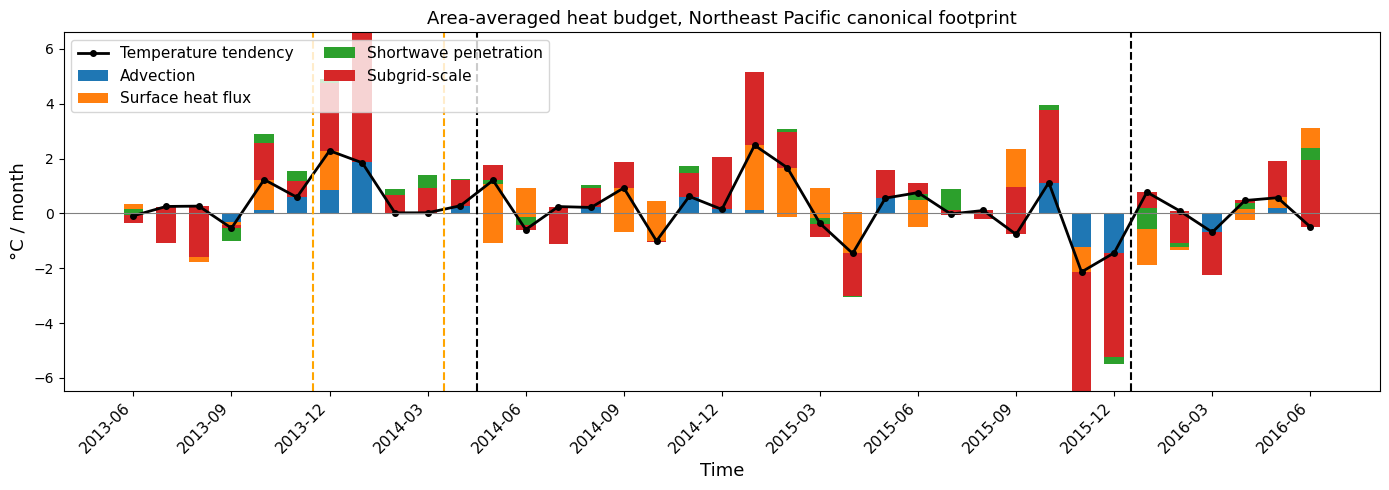

In [188]:
import matplotlib.pyplot as plt
import numpy as np

start, end = '2013-06', '2016-06'

tend = TEND_TEMP_areaavg_ext.sel(time=slice(start, end))
adv = TOT_ADV_areaavg_ext.sel(time=slice(start, end))
shf = SHF_depth_areaavg_ext.sel(time=slice(start, end))
qsw = QSW_3D_areaavg_ext.sel(time=slice(start, end))
subgrid = SUBGRID_areaavg_ext.sel(time=slice(start, end))

times = tend.time.values
x = np.arange(len(times))

fig, ax = plt.subplots(figsize=(14, 5))

width = 0.6
ax.bar(x, adv, width, label='Advection', color='#1f77b4')
ax.bar(x, shf, width, bottom=adv, label='Surface heat flux', color='#ff7f0e')
ax.bar(x, qsw, width, bottom=adv+shf, label='Shortwave penetration', color='#2ca02c')
ax.bar(x, subgrid, width, bottom=adv+shf+qsw, label='Subgrid-scale', color='#d62728')

ax.plot(x, tend, c='k', linewidth=2, marker='o', markersize=4, label='Temperature tendency')
ax.axhline(0, color='gray', linewidth=0.8)

# Mark event boundaries
precursor_start_idx = np.where([str(t)[:7]=='2013-12' for t in times])[0]
precursor_end_idx = np.where([str(t)[:7]=='2014-03' for t in times])[0]
blob_start_idx = np.where([str(t)[:7]=='2014-05' for t in times])[0]
blob_end_idx = np.where([str(t)[:7]=='2015-12' for t in times])[0]

if len(precursor_start_idx): ax.axvline(precursor_start_idx[0]-0.5, color='orange', linestyle='--', linewidth=1.5)
if len(precursor_end_idx): ax.axvline(precursor_end_idx[0]+0.5, color='orange', linestyle='--', linewidth=1.5)
if len(blob_start_idx): ax.axvline(blob_start_idx[0]-0.5, color='k', linestyle='--', linewidth=1.5)
if len(blob_end_idx): ax.axvline(blob_end_idx[0]+0.5, color='k', linestyle='--', linewidth=1.5)

# X-axis: year-month labels, sparse
tick_step = 3
ax.set_xticks(x[::tick_step])
ax.set_xticklabels([t.strftime('%Y-%m') for t in times[::tick_step]], rotation=45, ha='right', fontsize=11)

ax.set_ylabel('°C / month', fontsize=13)
ax.set_xlabel('Time', fontsize=13)
ax.legend(fontsize=11, loc='upper left', ncol=2)
ax.set_title('Area-averaged heat budget, Northeast Pacific canonical footprint', fontsize=13)

plt.tight_layout()
plt.show()

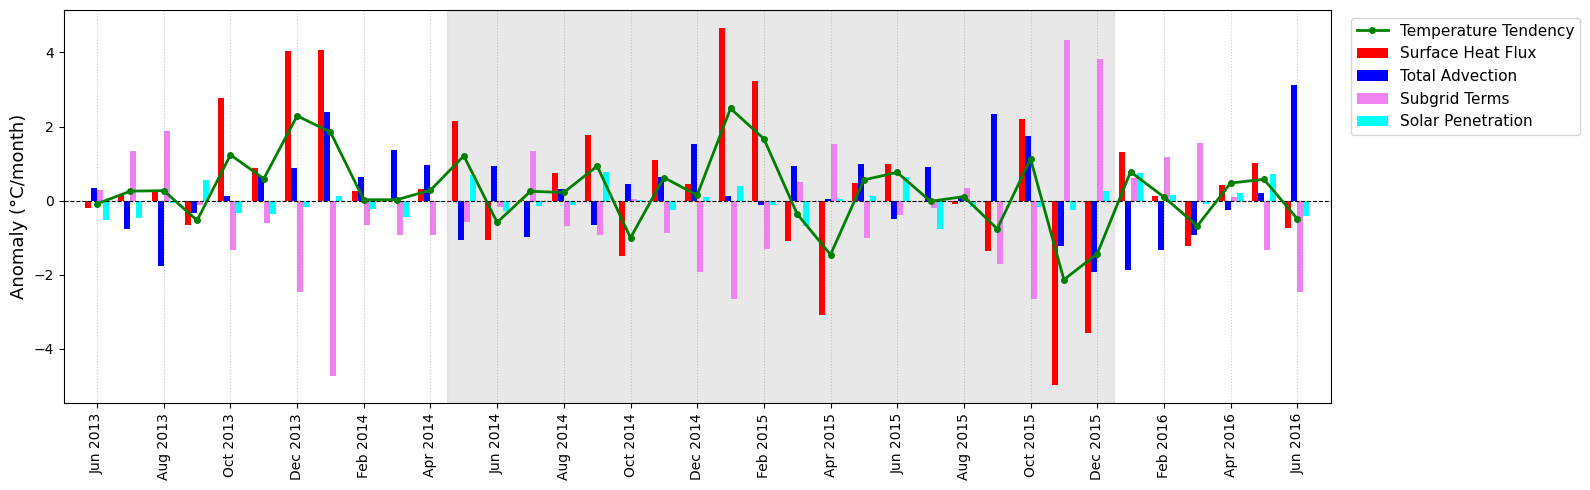

In [190]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

start, end = '2013-06', '2016-06'

tend = TEND_TEMP_areaavg_ext.sel(time=slice(start, end))
adv = TOT_ADV_areaavg_ext.sel(time=slice(start, end))
shf = SHF_depth_areaavg_ext.sel(time=slice(start, end))
qsw = QSW_3D_areaavg_ext.sel(time=slice(start, end))
subgrid = SUBGRID_areaavg_ext.sel(time=slice(start, end))

times = tend.time.values
x = np.arange(len(times))

fig, ax = plt.subplots(figsize=(10, 5))

# Gray shading for detected events
def shade_event(ax, times, start_str, end_str, color='lightgray'):
    idx = [i for i, t in enumerate(times) if start_str <= str(t)[:7] <= end_str]
    if idx:
        ax.axvspan(idx[0]-0.5, idx[-1]+0.5, color=color, alpha=0.5, zorder=0)

# shade_event(ax, times, '2013-12', '2014-03')  # precursor
shade_event(ax, times, '2014-05', '2015-12')  # main Blob

bar_width = 0.18
ax.bar(x - 1.5*bar_width, shf, bar_width, label='Surface Heat Flux', color='red')
ax.bar(x - 0.5*bar_width, adv, bar_width, label='Total Advection', color='blue')
ax.bar(x + 0.5*bar_width, subgrid, bar_width, label='Subgrid Terms', color='violet')
ax.bar(x + 1.5*bar_width, qsw, bar_width, label='Solar Penetration', color='cyan')

ax.plot(x, tend, c='green', linewidth=2, marker='o', markersize=4, label='Temperature Tendency', zorder=5)
ax.axhline(0, color='k', linestyle='--', linewidth=0.8)

# X-axis: month labels every ~2 months, vertical
tick_step = 2
ax.set_xticks(x[::tick_step])
ax.set_xticklabels([t.strftime('%b %Y') for t in times[::tick_step]], rotation=90, fontsize=10)

ax.set_ylabel('Anomaly (°C/month)', fontsize=13)
ax.set_xlim(-1, len(x))
ax.legend(fontsize=11, loc='upper left', bbox_to_anchor=(1.01, 1))
ax.grid(axis='x', linestyle=':', color='gray', alpha=0.4)

plt.tight_layout()
plt.show()

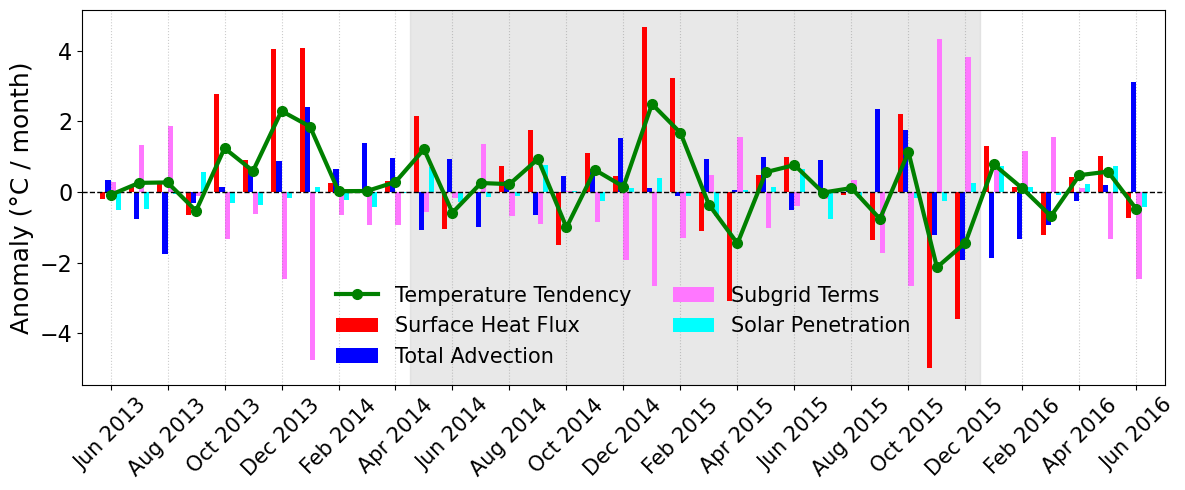

In [203]:
import matplotlib.pyplot as plt
import numpy as np

start, end = '2013-06', '2016-06'

tend = TEND_TEMP_areaavg_ext.sel(time=slice(start, end))
adv = TOT_ADV_areaavg_ext.sel(time=slice(start, end))
shf = SHF_depth_areaavg_ext.sel(time=slice(start, end))
qsw = QSW_3D_areaavg_ext.sel(time=slice(start, end))
subgrid = SUBGRID_areaavg_ext.sel(time=slice(start, end))

times = tend.time.values
x = np.arange(len(times))

fig, ax = plt.subplots(figsize=(12, 5))

def shade_event(ax, times, start_str, end_str, color='lightgray', alpha=0.5):
    idx = [i for i, t in enumerate(times) if start_str <= str(t)[:7] <= end_str]
    if idx:
        ax.axvspan(idx[0]-0.5, idx[-1]+0.5, color=color, alpha=alpha, zorder=0)

shade_event(ax, times, '2014-05', '2015-12', color='lightgray', alpha=0.5)

bar_width = 0.18
ax.bar(x - 1.5*bar_width, shf, bar_width, label='Surface Heat Flux', color='red')
ax.bar(x - 0.5*bar_width, adv, bar_width, label='Total Advection', color='blue')
ax.bar(x + 0.5*bar_width, subgrid, bar_width, label='Subgrid Terms', color='#FF77FF')
ax.bar(x + 1.5*bar_width, qsw, bar_width, label='Solar Penetration', color='cyan')

ax.plot(x, tend, c='green', linewidth=3, marker='o', markersize=7, label='Temperature Tendency', zorder=5)
ax.axhline(0, color='k', linestyle='--', linewidth=1)

# X-axis
tick_step = 2
ax.set_xticks(x[::tick_step])
ax.set_xticklabels([t.strftime('%b %Y') for t in times[::tick_step]],
                    rotation=45, fontsize=15)

ax.tick_params(axis='y', labelsize=16)
ax.set_ylabel('Anomaly (°C / month)', fontsize=18)
ax.set_xlim(-1, len(x))

ax.legend(fontsize=15, loc='lower center', ncol=2, frameon=False)
ax.grid(axis='x', linestyle=':', color='gray', alpha=0.4)

plt.tight_layout()
plt.show()

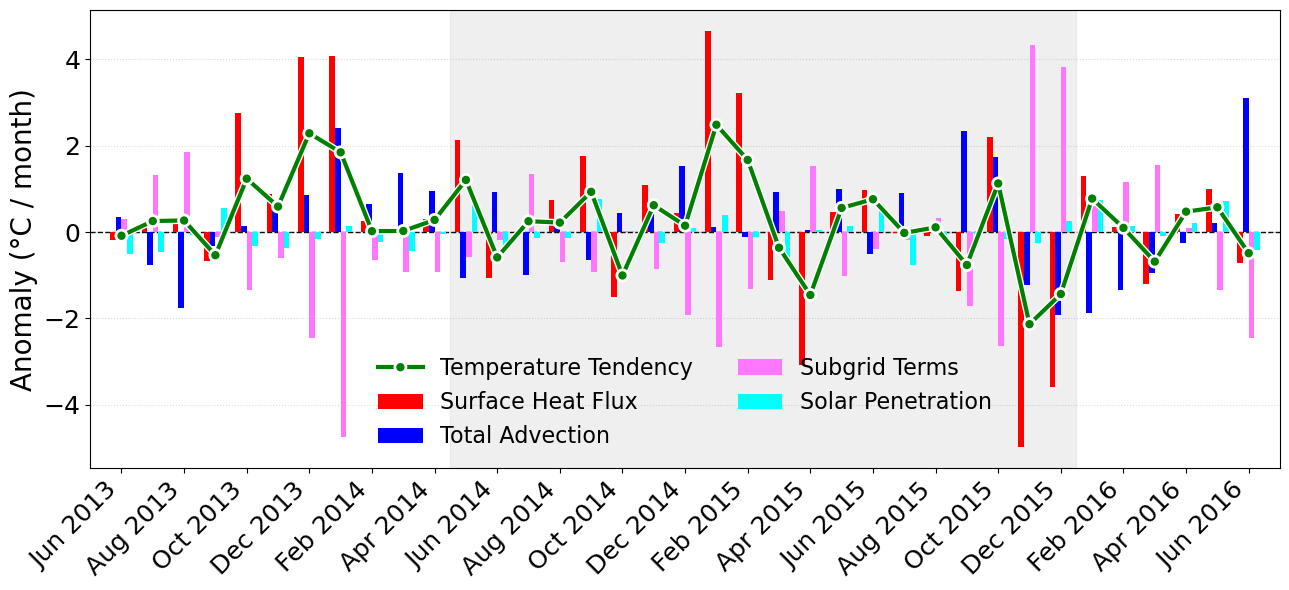

In [222]:
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(13, 6))

# shade_event(ax, times, '2013-12', '2014-03', color='purple', alpha=0.12)
shade_event(ax, times, '2014-05', '2015-12', color='lightgray', alpha=0.35)

bar_width = 0.18
ax.bar(x - 1.5*bar_width, shf, bar_width, label='Surface Heat Flux', color='red', alpha=1, zorder=2)
ax.bar(x - 0.5*bar_width, adv, bar_width, label='Total Advection', color='blue', alpha=1, zorder=2)
ax.bar(x + 0.5*bar_width, subgrid, bar_width, label='Subgrid Terms', color='#FF77FF', alpha=1, zorder=2)
ax.bar(x + 1.5*bar_width, qsw, bar_width, label='Solar Penetration', color='cyan', alpha=1, zorder=2)

ax.plot(x, tend, c='green', linewidth=3, marker='o', markersize=5,
        label='Temperature Tendency', zorder=10,
        path_effects=[pe.Stroke(linewidth=5, foreground='white'), pe.Normal()])

ax.axhline(0, color='k', linestyle='--', linewidth=1, zorder=1)

tick_step = 2
ax.set_xticks(x[::tick_step])
ax.set_xticklabels([t.strftime('%b %Y') for t in times[::tick_step]],
                    rotation=45, ha='right', fontsize=18)
ax.tick_params(axis='y', labelsize=18)
ax.set_ylabel('Anomaly (°C / month)', fontsize=20)
ax.set_xlim(-1, len(x))

ax.legend(fontsize=16, loc='lower center', ncol=2, frameon=False)
ax.grid(axis='y', linestyle=':', color='gray', alpha=0.3, zorder=0)

plt.tight_layout()
plt.show()

In [241]:
start, end = '2013-09', '2016-04'

tend = TEND_TEMP_areaavg_ext.sel(time=slice(start, end))
adv = TOT_ADV_areaavg_ext.sel(time=slice(start, end))
shf = SHF_depth_areaavg_ext.sel(time=slice(start, end))
qsw = QSW_3D_areaavg_ext.sel(time=slice(start, end))
subgrid = SUBGRID_areaavg_ext.sel(time=slice(start, end))

times = tend.time.values
x = np.arange(len(times))

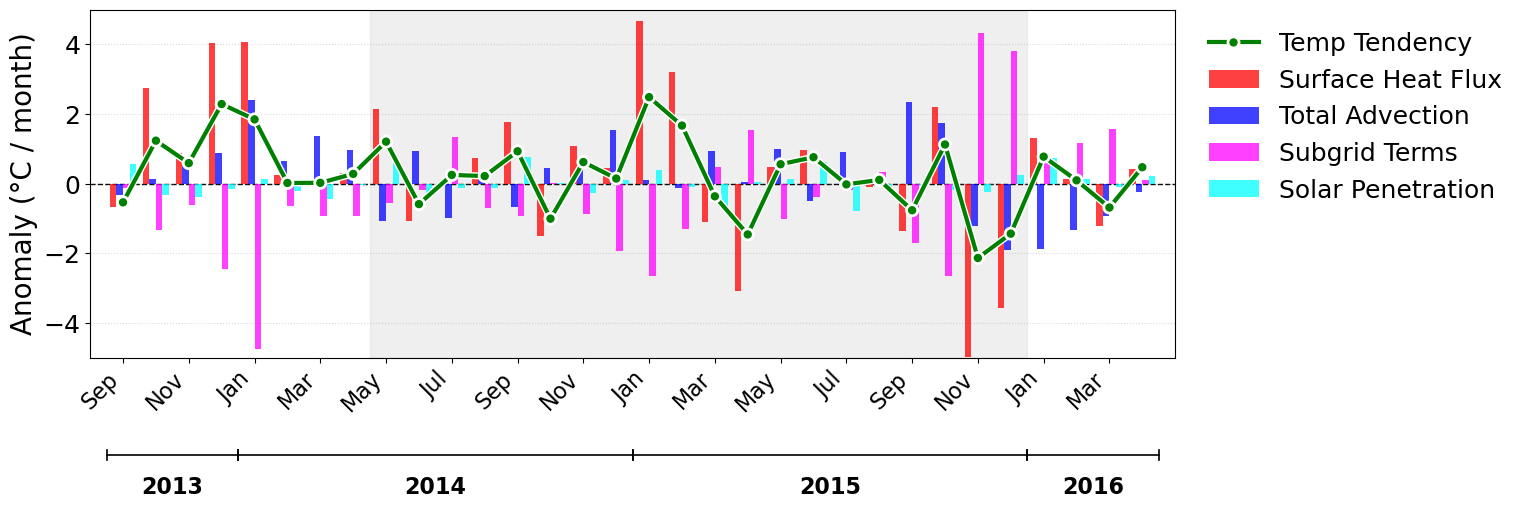

In [249]:
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(14, 6))

# shade_event(ax, times, '2013-12', '2014-03', color='purple', alpha=0.12)
shade_event(ax, times, '2014-05', '2015-12', color='lightgray', alpha=0.35)

bar_width = 0.2
ax.bar(x - 1.5*bar_width, shf, bar_width, label='Surface Heat Flux', color='red', alpha=0.75, zorder=2)
ax.bar(x - 0.5*bar_width, adv, bar_width, label='Total Advection', color='blue', alpha=0.75, zorder=2)
ax.bar(x + 0.5*bar_width, subgrid, bar_width, label='Subgrid Terms', color='fuchsia', alpha=0.75, zorder=2)
ax.bar(x + 1.5*bar_width, qsw, bar_width, label='Solar Penetration', color='cyan', alpha=0.75, zorder=2)

ax.plot(x, tend, c='green', linewidth=3, marker='o', markersize=5,
        label='Temp Tendency', zorder=10,
        path_effects=[pe.Stroke(linewidth=5, foreground='white'), pe.Normal()])

ax.axhline(0, color='k', linestyle='--', linewidth=1, zorder=1)

# --- Month tick labels ---
tick_step = 2
tick_positions = x[::tick_step]
tick_times = times[::tick_step]

month_labels = [t.strftime('%b') for t in tick_times]
ax.set_xticks(tick_positions)
ax.set_xticklabels(month_labels, rotation=45, ha='right', fontsize=16)

ax.tick_params(axis='y', labelsize=18)
ax.set_ylabel('Anomaly (°C / month)', fontsize=20)
ax.set_xlim(-1, len(x))

ax.legend(fontsize=18, loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False, ncol=1)
# ax.legend(fontsize=15, loc='lower center', ncol=2, frameon=False)
ax.grid(axis='y', linestyle=':', color='gray', alpha=0.3, zorder=0)

plt.subplots_adjust(bottom=0.3)
fig.canvas.draw()  # needed so transforms below resolve correctly

# --- Year brackets + labels, drawn in figure-transform coordinates below the axis ---
years_present = sorted(set(t.year for t in times))
trans = ax.get_xaxis_transform()  # x in data coords, y in axes-fraction coords

bracket_y = -0.28   # vertical position of the bracket line (axes fraction, negative = below plot)
label_y   = -0.34   # vertical position of the year label, just below the bracket

for yr in years_present:
    idx_in_year = [i for i, t in enumerate(times) if t.year == yr]
    if not idx_in_year:
        continue
    x_start = idx_in_year[0] - 0.5
    x_end = idx_in_year[-1] + 0.5
    x_mid = (x_start + x_end) / 2

    # Horizontal bracket line
    ax.plot([x_start, x_end], [bracket_y, bracket_y],
             color='k', linewidth=1.2, transform=trans, clip_on=False)
    # Small vertical ticks at each end of the bracket
    tick_h = 0.015
    ax.plot([x_start, x_start], [bracket_y - tick_h, bracket_y + tick_h],
             color='k', linewidth=1.2, transform=trans, clip_on=False)
    ax.plot([x_end, x_end], [bracket_y - tick_h, bracket_y + tick_h],
             color='k', linewidth=1.2, transform=trans, clip_on=False)

    # Year label centered under the bracket
    ax.text(x_mid, label_y, str(yr), transform=trans,
            ha='center', va='top', fontsize=16, fontweight='bold', clip_on=False)
plt.ylim(-5, 5)
plt.show()

In [179]:
TEND_TEMP_notrend_smaller_reg_nan = xr.where(TEND_TEMP_notrend_smaller_reg == 0., np.nan, TEND_TEMP_notrend_smaller_reg)
TOT_ADV_notrend_smaller_reg_nan = xr.where(TOT_ADV_notrend_smaller_reg == 0., np.nan, TOT_ADV_notrend_smaller_reg)
SHF_depth_notrend_smaller_reg_nan = xr.where(SHF_depth_notrend_smaller_reg == 0., np.nan, SHF_depth_notrend_smaller_reg)
QSW_3D_notrend_smaller_reg_nan = xr.where(QSW_3D_notrend_smaller_reg == 0., np.nan, QSW_3D_notrend_smaller_reg)
SUBGRID_notrend_smaller_reg_nan = xr.where(SUBGRID_notrend_smaller_reg == 0., np.nan, SUBGRID_notrend_smaller_reg)

In [164]:
TOT_ADV = fosi_heat_budget['TOTADV']
SHF_depth = fosi_heat_budget['SHF_depth']
QSW_3D = fosi_heat_budget['QSW_3D']
SUBGRID = fosi_heat_budget['Subgrid']

TOT_ADV_nan = xr.where(TOT_ADV == 0., np.nan, TOT_ADV) * NO_SEC_IN_1_MON
SHF_depth_nan = xr.where(SHF_depth == 0., np.nan, SHF_depth) * NO_SEC_IN_1_MON
QSW_3D_nan = xr.where(QSW_3D == 0., np.nan, QSW_3D) * NO_SEC_IN_1_MON
SUBGRID_nan = xr.where(SUBGRID == 0., np.nan, SUBGRID) * NO_SEC_IN_1_MON

mean, trend, seasonal, TEND_TEMP_notrend = afuncs.calculate_pop_grid_anomalies_trend_features(TEND_TEMP_nan)
mean, trend, seasonal, TOT_ADV_notrend = afuncs.calculate_pop_grid_anomalies_trend_features(TOT_ADV_nan)
mean, trend, seasonal, SHF_depth_notrend = afuncs.calculate_pop_grid_anomalies_trend_features(SHF_depth_nan)
mean, trend, seasonal, QSW_3D_notrend = afuncs.calculate_pop_grid_anomalies_trend_features(QSW_3D_nan)
mean, trend, seasonal, SUBGRID_notrend = afuncs.calculate_pop_grid_anomalies_trend_features(SUBGRID_nan)

In [ ]:
TEND_TEMP_notrend_smaller_reg = TEND_TEMP_notrend * NEPac_MHW_renamed_latlon
TOT_ADV_notrend_smaller_reg = TOT_ADV_notrend * NEPac_MHW_renamed_latlon
SHF_depth_notrend_smaller_reg = SHF_depth_notrend * NEPac_MHW_renamed_latlon
QSW_3D_notrend_smaller_reg = QSW_3D_notrend * NEPac_MHW_renamed_latlon
SUBGRID_notrend_smaller_reg = SUBGRID_notrend * NEPac_MHW_renamed_latlon

TEND_TEMP_notrend_smaller_reg_nan = xr.where(TEND_TEMP_notrend_smaller_reg == 0., np.nan, TEND_TEMP_notrend_smaller_reg)
TOT_ADV_notrend_smaller_reg_nan = xr.where(TOT_ADV_notrend_smaller_reg == 0., np.nan, TOT_ADV_notrend_smaller_reg)
SHF_depth_notrend_smaller_reg_nan = xr.where(SHF_depth_notrend_smaller_reg == 0., np.nan, SHF_depth_notrend_smaller_reg)
QSW_3D_notrend_smaller_reg_nan = xr.where(QSW_3D_notrend_smaller_reg == 0., np.nan, QSW_3D_notrend_smaller_reg)
SUBGRID_notrend_smaller_reg_nan = xr.where(SUBGRID_notrend_smaller_reg == 0., np.nan, SUBGRID_notrend_smaller_reg)